In [1]:
import sys
sys.path.insert(0, '../2d')

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from model import SimpleCNN2DAttentionClassifier
from dataset import OASIS2DDataset

CHECKPOINT = '../checkpoints/2d_cv5/fold_0/best_model.pth'
DATA_DIR   = '../data/processed_oasis_2d_cv5'
FOLD       = 1
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
model = SimpleCNN2DAttentionClassifier(
    in_channels=1, num_classes=2, num_slices=120,
    base_channels=32, dropout=0.3, use_content_based=True
)
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE).eval()
print(f"Loaded checkpoint (epoch {ckpt.get('epoch')}, best_val_acc {ckpt.get('best_val_acc', 'N/A')})")


Loaded checkpoint (epoch 22, best_val_acc 0.8208955223880597)


In [4]:
dataset = OASIS2DDataset(DATA_DIR, fold=FOLD, split='val')
loader  = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)

all_labels, all_preds, all_attn = [], [], []

with torch.no_grad():
    for images, labels, _ in loader:
        images = images.to(DEVICE)
        logits, attn = model(images, return_attention=True)
        preds = torch.argmax(logits, dim=1)
        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())
        all_attn.append(attn.cpu())

all_labels = torch.cat(all_labels).numpy()
all_preds  = torch.cat(all_preds).numpy()
all_attn   = torch.cat(all_attn).numpy()   # (N, 120)

tp_idx = np.where((all_labels == 1) & (all_preds == 1))[0]
tn_idx = np.where((all_labels == 0) & (all_preds == 0))[0]
print(f"TP: {len(tp_idx)}, TN: {len(tn_idx)}")


Loaded val data for fold 1: 67 subjects
  Shape: (67, 224, 224, 120)
  Normal: 51, Alzheimer: 16
TP: 11, TN: 51


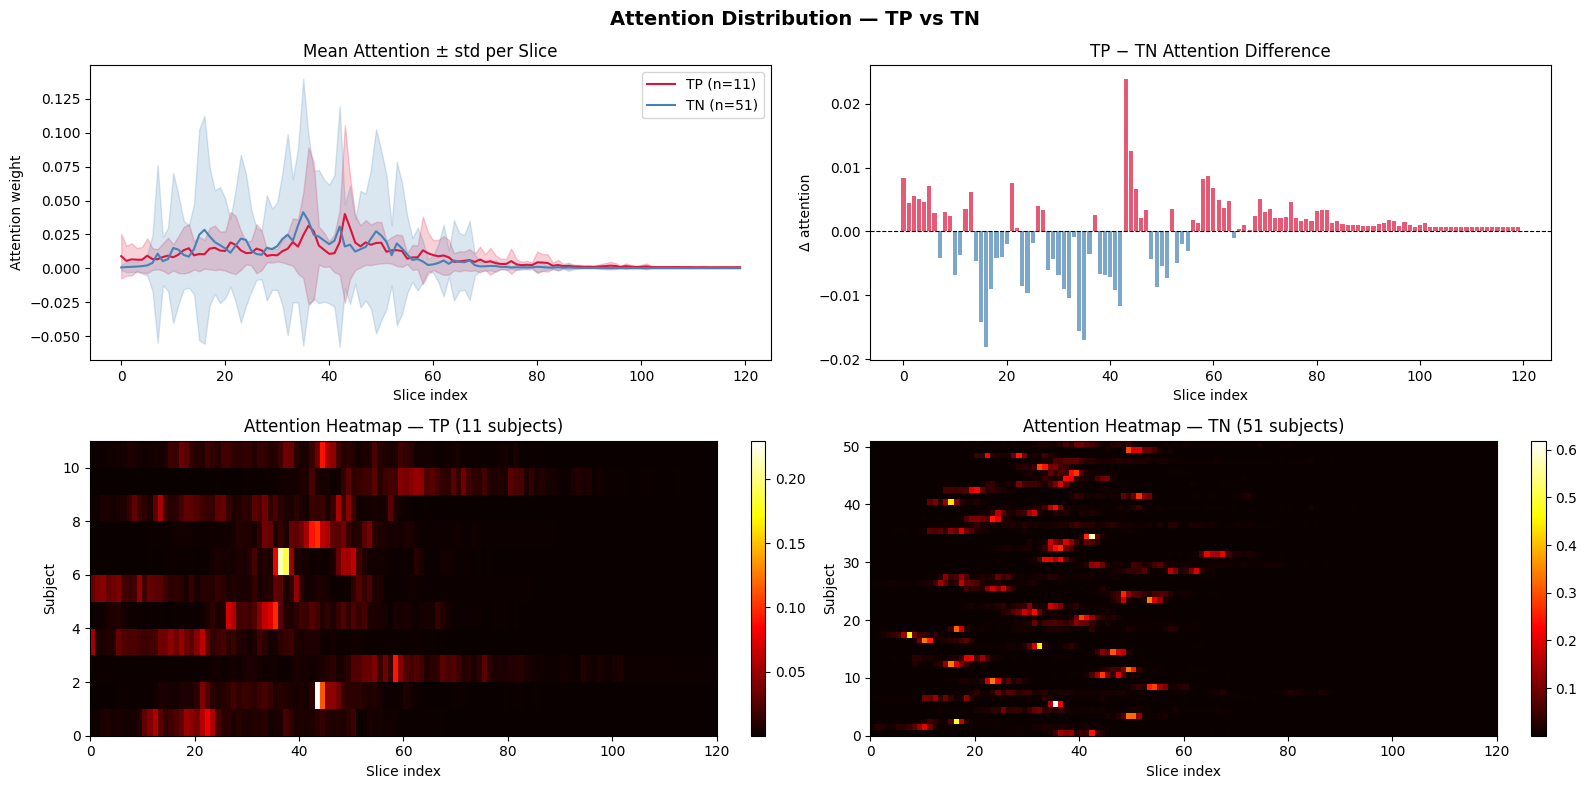

In [5]:
slice_axis = np.arange(120)

tp_attn_mean = all_attn[tp_idx].mean(axis=0)
tn_attn_mean = all_attn[tn_idx].mean(axis=0)
tp_attn_std  = all_attn[tp_idx].std(axis=0)
tn_attn_std  = all_attn[tn_idx].std(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Attention Distribution — TP vs TN', fontsize=14, fontweight='bold')

# --- mean attention curves ---
ax = axes[0, 0]
ax.plot(slice_axis, tp_attn_mean, color='crimson',   lw=1.5, label=f'TP (n={len(tp_idx)})')
ax.fill_between(slice_axis, tp_attn_mean - tp_attn_std, tp_attn_mean + tp_attn_std,
                color='crimson', alpha=0.2)
ax.plot(slice_axis, tn_attn_mean, color='steelblue', lw=1.5, label=f'TN (n={len(tn_idx)})')
ax.fill_between(slice_axis, tn_attn_mean - tn_attn_std, tn_attn_mean + tn_attn_std,
                color='steelblue', alpha=0.2)
ax.set_title('Mean Attention ± std per Slice')
ax.set_xlabel('Slice index')
ax.set_ylabel('Attention weight')
ax.legend()

# --- difference curve ---
ax = axes[0, 1]
diff = tp_attn_mean - tn_attn_mean
ax.bar(slice_axis, diff,
       color=['crimson' if d > 0 else 'steelblue' for d in diff], alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('TP − TN Attention Difference')
ax.set_xlabel('Slice index')
ax.set_ylabel('Δ attention')

# --- heatmap TP ---
ax = axes[1, 0]
im = ax.imshow(all_attn[tp_idx], aspect='auto', cmap='hot',
               extent=[0, 120, 0, len(tp_idx)])
ax.set_title(f'Attention Heatmap — TP ({len(tp_idx)} subjects)')
ax.set_xlabel('Slice index')
ax.set_ylabel('Subject')
fig.colorbar(im, ax=ax, fraction=0.03)

# --- heatmap TN ---
ax = axes[1, 1]
im = ax.imshow(all_attn[tn_idx], aspect='auto', cmap='hot',
               extent=[0, 120, 0, len(tn_idx)])
ax.set_title(f'Attention Heatmap — TN ({len(tn_idx)} subjects)')
ax.set_xlabel('Slice index')
ax.set_ylabel('Subject')
fig.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.show()
